# Data Preprocessing

This notebook is the entry point for rebuilding the clean analysis tables from the raw Lernnavi logs. The goal is to make the later notebooks independent from the older exploratory preprocessing notebooks: all cleaning, calendar features, user-relative weeks, Stage 1 aggregates, and Stage 2 weekly features are delegated to `src/preprocess.py`.

The preprocessing follows the two-stage project design. Stage 1 compresses the first weeks of activity into one row per learner, while Stage 2 keeps a weekly trajectory so that temporal changes in engagement can be modeled explicitly.


## Setup


In [4]:
from pathlib import Path
import json

import pandas as pd

PROJECT_ROOT = Path.cwd().resolve()

from src.preprocess import build_stage1_dataset, build_stage2_dataset, load_clean_data

import matplotlib.pyplot as plt

DATA_DIR = PROJECT_ROOT / "data"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 140)

print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"DATA_DIR exists: {DATA_DIR.exists()}")
print(f"OUTPUT_DIR: {OUTPUT_DIR}")


PROJECT_ROOT: C:\Users\loicm\Documents\EPFL\2025-2026\MA4\ML_for_BD\CS-421-Project-learnavi
DATA_DIR exists: True
OUTPUT_DIR: C:\Users\loicm\Documents\EPFL\2025-2026\MA4\ML_for_BD\CS-421-Project-learnavi\outputs


## Build Clean Tables


In [2]:
clean = load_clean_data(DATA_DIR)
stage1 = build_stage1_dataset(DATA_DIR)
stage2 = build_stage2_dataset(DATA_DIR)

users_clean = clean.users
events_clean = clean.events
transactions_clean = clean.transactions
stage1_df = stage1.df
stage1_feature_cols = stage1.feature_cols
df_full = stage2.df_full
feature_cols = stage2.feature_cols
user_features = stage2.user_features

print(f"users_clean: {users_clean.shape}")
print(f"events_clean: {events_clean.shape}")
print(f"transactions_clean: {transactions_clean.shape}")
print(f"stage1_df: {stage1_df.shape}")
print(f"df_full: {df_full.shape}")
print(f"Stage 1 features: {len(stage1_feature_cols)}")
print(f"Stage 2 weekly features: {len(feature_cols)}")


users_clean: (30929, 6)
events_clean: (11193171, 21)
transactions_clean: (2134759, 34)
stage1_df: (22466, 90)
df_full: (408377, 23)
Stage 1 features: 88
Stage 2 weekly features: 17


## Quick Checks


In [3]:
display(users_clean.head())
display(stage1_df.head())
display(df_full[["user_id", "relative_week", "is_dropout_point", "is_summer"]].head(10))

print("Stage 2 feature columns:")
print(feature_cols)
print()
print("Missing dropout labels:", int(df_full["is_dropout_point"].isna().sum()))


,user_id,gender,canton,class_level,study,class_id
0,387604,Unknown,Unknown,Unknown,False,Unknown
1,387605,Unknown,Unknown,Unknown,False,Unknown
2,387608,Unknown,Unknown,Unknown,True,9Q2M7
3,387613,Unknown,Unknown,Unknown,False,Unknown
4,387615,MALE,SG,Gymnasium - 3. Jahr,False,Unknown


,user_id,total_events_0_2,n_active_days_0_2,n_click_events_0_2,n_view_events_0_2,n_sessions_0_2,n_topics_event_0_2,mean_hour_0_2,std_hour_0_2,total_transactions_0_2,correct_rate_0_2,partial_rate_0_2,mean_evaluation_score_0_2,avg_response_time_0_2,n_documents_0_2,n_topics_transaction_0_2,std_evaluation_score_0_2,std_response_time_0_2,session_duration_mean_0_2,session_duration_std_0_2,time_between_sessions_mean_0_2,retry_ratio_0_2,review_rate_0_2,study,class_year,gender_FEMALE,gender_MALE,gender_Other,gender_Unknown,canton_AG,canton_AI,canton_AR,canton_Andere,canton_BE,canton_BL,canton_BS,canton_FL,canton_FR,canton_GL,canton_GR,canton_JU,canton_LU,canton_NE,canton_SG,canton_SH,canton_SO,canton_SZ,canton_TG,canton_UR,canton_Unknown,canton_VD,canton_VS,canton_ZG,canton_ZH,school_2. Klasse LG,school_3. Klasse LG,school_4. Klasse LG,school_5. Klasse LG,school_6. Klasse LG,school_7. Klasse LG,school_BME,school_BME (Matura),school_FM,school_FM (Fachmaturität),school_FMS,school_Fachmaturität Pädagogik,school_Gymnasium,school_HMS,school_IMS,school_ISME,school_ISME (Matura),school_K+S,school_KME Passerelle,school_KME Teilzeit,school_KME Vollzeit,school_Keine Angabe,school_Kurzzeitgymnasium,school_Langzeitgymnasium,school_Liceo Artistico,school_Maturität für Erwachsene,school_Passerelle,school_Passerelle BM/FM,school_Sekundarschule P,school_UG,school_Unknown,school_Vorkurs PH für Berufsleute,school_Vorkurs Pädagogik,school_WMS,school_andere,came_back
0,387604,2.0,2.0,0.0,2.0,0.0,0.0,9.000000,5.656854,2,0.000000,0.000000,0.000000,0.000000,1,0,0.000000,0.000000,0.0000,0.000000,0.000,2.000000,0.000000,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1
1,387605,12.0,1.0,7.0,5.0,2.0,2.0,6.000000,0.000000,5,0.400000,0.200000,0.500000,39.957000,5,2,0.500000,8.813259,67.9890,91.349711,11.093,1.000000,0.000000,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1
2,387608,101.0,2.0,35.0,66.0,2.0,1.0,8.603960,1.225391,34,0.382353,0.058824,0.411765,26.930133,15,1,0.484152,17.598100,268.7685,140.867692,213.765,2.266667,1.000000,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1
3,387613,11.0,1.0,3.0,8.0,1.0,1.0,12.000000,0.000000,2,0.500000,0.000000,0.500000,24.976000,2,1,0.707107,0.000000,40.1110,0.000000,0.000,1.000000,2.000000,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1
4,387615,348.0,6.0,76.0,272.0,2.0,1.0,9.784483,2.961246,37,0.270270,0.081081,0.310811,46.730929,19,1,0.446458,47.616260,428.2360,176.792252,14.439,1.947368,1.428571,0,3,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1


,user_id,relative_week,is_dropout_point,is_summer
0,387604,0,0.0,False
1,387604,1,0.0,False
2,387604,2,0.0,False
3,387604,3,0.0,False
4,387604,4,0.0,False
5,387604,5,0.0,False
6,387604,6,0.0,True
7,387604,7,0.0,True
8,387604,8,0.0,True
9,387604,9,0.0,True


Stage 2 feature columns:
['n_events', 'n_active_days', 'mean_hour', 'n_click_events', 'n_view_events', 'n_sessions', 'n_topics_event', 'n_transactions', 'correct_rate', 'partial_rate', 'mean_evaluation_score', 'avg_response_time', 'n_documents', 'n_topics_transaction', 'activity_score', 'year', 'day']

Missing dropout labels: 65533


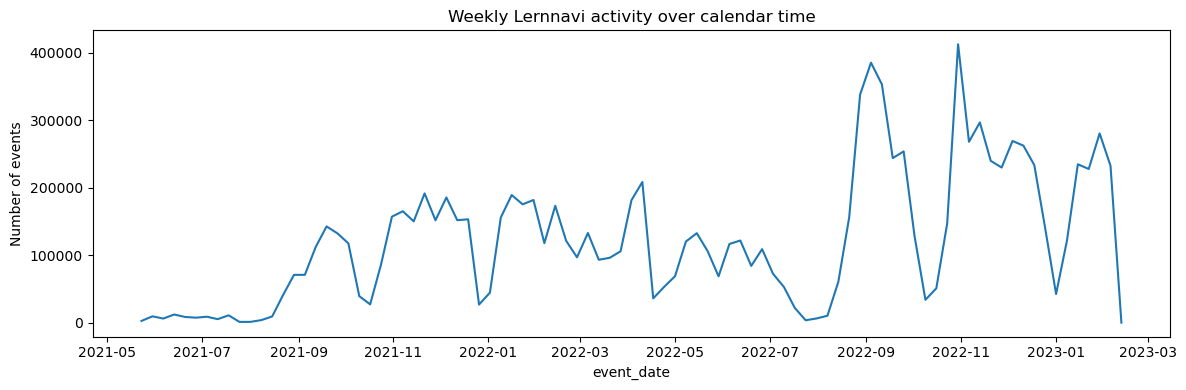

In [5]:
events_for_plot = events_clean.copy()
events_for_plot["event_date"] = pd.to_datetime(events_for_plot["event_date"])

weekly_event_counts = (
    events_for_plot
    .set_index("event_date")
    .resample("W")
    .size()
    .rename("n_events")
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(weekly_event_counts["event_date"], weekly_event_counts["n_events"])

ax.set_xlabel("event_date")
ax.set_ylabel("Number of events")
ax.set_title("Weekly Lernnavi activity over calendar time")

plt.tight_layout()
plt.show()

# Notes and outputs

The outputs produced here are intermediate artifacts for inspection and reproducibility. The modeling notebooks can also call `build_stage1_dataset` and `build_stage2_dataset` directly, so this notebook is mainly useful when we want to audit the generated tables or export a clean snapshot.

Key checks after rerunning this notebook are the number of learners, the label balance, and the feature list for each stage. These sanity checks make sure that later modeling results are driven by the intended cohort definition rather than by accidental preprocessing drift.


In [6]:
users_clean.to_csv(OUTPUT_DIR / "users_clean.csv", index=False)
events_clean.to_csv(OUTPUT_DIR / "events_clean.csv", index=False)
transactions_clean.to_csv(OUTPUT_DIR / "transactions_clean.csv", index=False)
stage1_df.to_csv(OUTPUT_DIR / "stage1.csv", index=False)
user_features.to_csv(OUTPUT_DIR / "stage2_user_features.csv", index=False)
df_full.to_csv(OUTPUT_DIR / "stage2_weekly_timeline.csv", index=False)

with open(OUTPUT_DIR / "stage1_feature_cols.json", "w", encoding="utf-8") as handle:
    json.dump(stage1_feature_cols, handle, indent=2)

with open(OUTPUT_DIR / "stage2_feature_cols.json", "w", encoding="utf-8") as handle:
    json.dump(feature_cols, handle, indent=2)

print("Saved files:")
for output_path in sorted(OUTPUT_DIR.iterdir()):
    print(f"- {output_path.name}")


Saved files:
- events_clean.csv
- stage1.csv
- stage1_feature_cols.json
- stage2_feature_cols.json
- stage2_user_features.csv
- stage2_weekly_timeline.csv
- transactions_clean.csv
- users_clean.csv
